In [1]:
import pandas as pd
import numpy as np

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, log_loss

import xgboost as xgb
from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
iris = datasets.load_iris(as_frame=True).frame
iris#.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [7]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [8]:
target = 'target'

In [9]:
iris[target].value_counts(normalize=True).round(2)

target
0    0.33
1    0.33
2    0.33
Name: proportion, dtype: float64

## XGBoost Modelinin Qurulması və Datanın Bölünməsi

In [10]:
features = iris.drop(columns=[target]).columns.to_list()
X = iris[features]
y = iris[target]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

print(f"Train set ölçüsü: {X_train.shape}")
print(f"Test set ölçüsü: {X_test.shape}")

Train set ölçüsü: (120, 4)
Test set ölçüsü: (30, 4)


## XGBoost Təlimi (Multinomial Classification)

In [12]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=123,
    eval_metric='mlogloss'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [ ]:
# Crossvalidation

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(f"10-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

10-Fold Cross-Validation Accuracy: 0.9533 (+/- 0.0521)


## Proqnozlar

In [23]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

pd.DataFrame(y_proba).head()

,0,1,2
0,0.006378,0.980411,0.013210
1,0.991310,0.006627,0.002063
2,0.002055,0.002769,0.995176
3,0.002147,0.004495,0.993358
4,0.991310,0.006627,0.002063


In [24]:
pred_df = pd.DataFrame(y_proba, columns=[f'prob_class_{i}' for i in range(3)])
pred_df.head()

,prob_class_0,prob_class_1,prob_class_2
0,0.006378,0.980411,0.013210
1,0.991310,0.006627,0.002063
2,0.002055,0.002769,0.995176
3,0.002147,0.004495,0.993358
4,0.991310,0.006627,0.002063


In [25]:
pred_df['predict'] = y_pred
pred_df['actual'] = y_test.values
pred_df.head(10)

,prob_class_0,prob_class_1,prob_class_2,predict,actual
0,0.006378,0.980411,0.013210,1,1
1,0.991310,0.006627,0.002063,0,0
2,0.002055,0.002769,0.995176,2,2
3,0.002147,0.004495,0.993358,2,2
4,0.991310,0.006627,0.002063,0,0
5,0.991310,0.006627,0.002063,0,0
6,0.001804,0.002103,0.996093,2,2
7,0.007898,0.888759,0.103343,1,1
8,0.026690,0.683434,0.289876,1,2
9,0.991310,0.006627,0.002063,0,0


## Qarışıqlıq matrisi

In [26]:
actual = y_test.values
pred_class = y_pred

y_true = np.asarray(actual, dtype=int)
y_preds = np.asarray(pred_class, dtype=int)

cm = confusion_matrix(y_true, y_preds, labels=[0, 1, 2])
cm

array([[10,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  9]], dtype=int64)

In [27]:
cm_df = pd.DataFrame(
    cm,
    index=pd.Index([0, 1, 2], name="Actual"),
    columns=pd.Index([0, 1, 2], name="Predicted")
)
cm_df

Predicted,0,1,2
Actual,,,
0,10,0,0
1,0,9,1
2,0,1,9


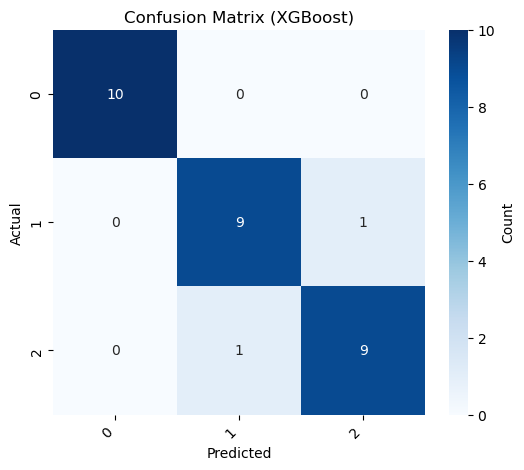

In [28]:
plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_df,
    annot=True, fmt="d",
    cmap="Blues", vmin=0,
    cbar_kws={"label": "Count"}
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (XGBoost)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()

In [29]:
(10 + 9 + 9) / (10 + 9 + 9 + 1 + 1)

0.9333333333333333

## Model Qiymətləndirilməsi və Əhəmiyyətli Xüsusiyyətlər (Feature Importance)

In [30]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['(0)', '(1)', '(2)']))

Classification Report:

              precision    recall  f1-score   support

         (0)       1.00      1.00      1.00        10
         (1)       0.90      0.90      0.90        10
         (2)       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



<Figure size 800x400 with 0 Axes>

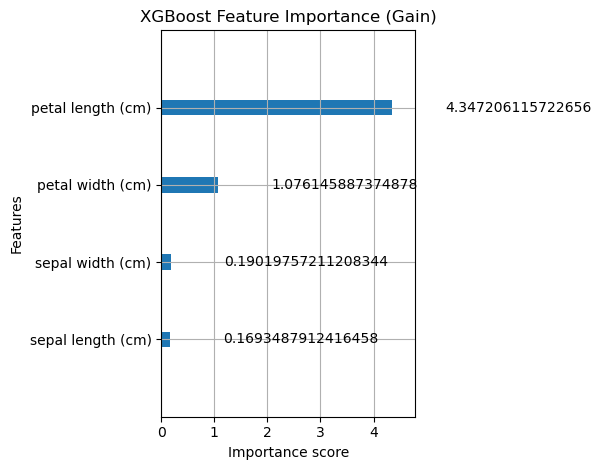

In [31]:
plt.figure(figsize=(8, 4))
ax = xgb.plot_importance(model, importance_type='gain', title='XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()